In [106]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

In [2]:
df = pd.read_csv("sales_cleaned.csv")

In [3]:
df.head()

,Unnamed: 0,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,0,TXN_1000555,Tea,1,1.5,1.5,Credit Card,In-store,2023-10-19
1,1,TXN_1002457,Cookie,5,1.0,5.0,Digital Wallet,Takeaway,2023-09-29
2,2,TXN_1004184,Smoothie,1,4.0,4.0,Credit Card,In-store,2023-05-18
3,3,TXN_1004563,Tea,5,1.5,7.5,Credit Card,In-store,2023-10-28
4,4,TXN_1005331,Coffee,1,2.0,2.0,Digital Wallet,Takeaway,2023-11-04


In [4]:
df.groupby("Item")["Quantity"].agg(["mean", "median"])

,mean,median
Item,,
Cake,3.046753,3.0
Coffee,3.054496,3.0
Cookie,2.974425,3.0
Juice,2.915691,3.0
Salad,3.043062,3.0
Sandwich,3.051151,3.0
Smoothie,3.023669,3.0
Tea,3.094086,3.0


In [7]:
df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

Item
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Juice       3735.0
Cake        3519.0
Coffee      2242.0
Tea         1726.5
Cookie      1163.0
Name: Total Spent, dtype: float64

In [108]:
#Plotting total spent per item on bar chart

fig = px.bar(df.groupby("Item", as_index=False)["Total Spent"].sum(), x = "Item", y="Total Spent", title = "Total Spent per Item")
fig.show(renderer = "browser")

Salad is the most item generating most revenue. 

In [109]:
#Plotting common payment methods on pie chart

fig = px.pie(df, values = df["Payment Method"].value_counts(), names = df["Payment Method"].unique(), title = "Common Payment Methods")
fig.show(renderer="browser")

All three payment methods seem to be used equally. 

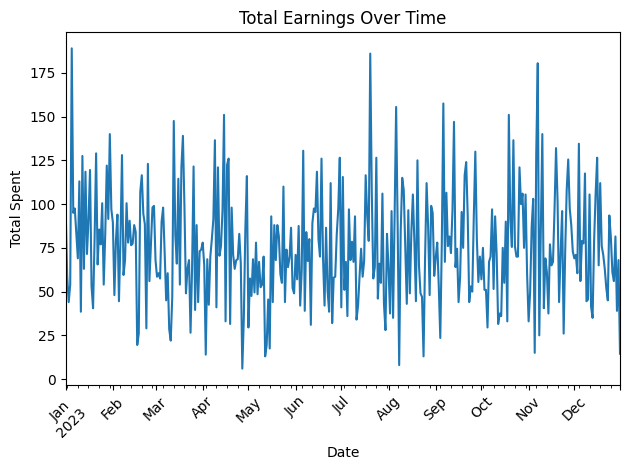

In [17]:
daily_earnings = df.groupby("Transaction Date")["Total Spent"].sum()

daily_earnings.sort_index().plot(kind="line")

plt.title("Total Earnings Over Time")
plt.xlabel("Date")
plt.ylabel("Total Spent")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

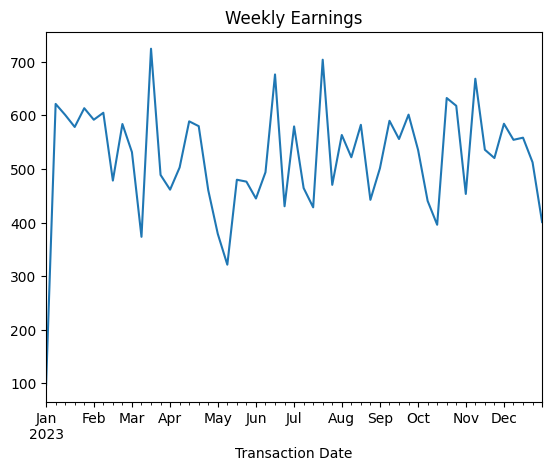

In [18]:
weekly = df.set_index("Transaction Date")["Total Spent"].resample("W").sum()
weekly.plot()
plt.title("Weekly Earnings")
plt.show()

In [21]:


fig = go.Figure([go.Scatter(x=weekly.index, y=weekly.values)])
fig.show(renderer="browser")

In [23]:
df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Item', 'Quantity', 'Price Per Unit',
       'Total Spent', 'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [29]:
print("Total revenue of the cafe is (GBP):", df["Total Spent"].sum())
print("Average order value is (GBP):", df["Total Spent"].mean())
print("Median order quantity is (GBP):", df["Quantity"].median())

Total revenue of the cafe is (GBP): 27605.5
Average order value is (GBP): 8.936710909679508
Median order quantity is (GBP): 3.0


In [31]:
df["Day of Week"] = df["Transaction Date"].dt.day_name()

<function matplotlib.pyplot.show(close=None, block=None)>

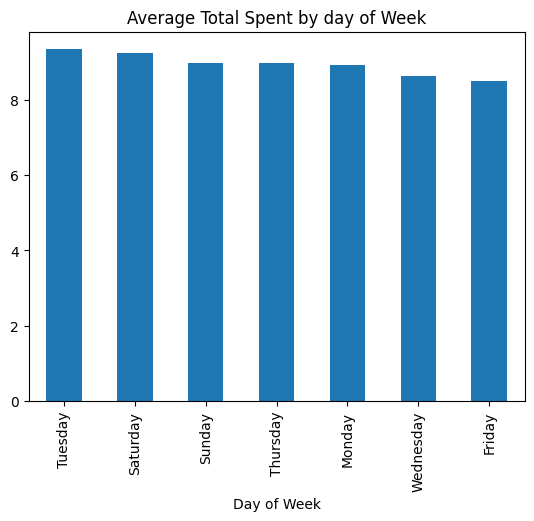

In [40]:
df.groupby("Day of Week")["Total Spent"].mean().sort_values(ascending=False).plot(kind="bar")
xlabel="Day of Week"
ylabel="Total Spent"
plt.title("Average Total Spent by day of Week")
plt.show

In [45]:
#Get daily sales and 7-day and 30-day rolling averages

Daily_Sales = (df.groupby("Transaction Date")["Total Spent"].sum().sort_index())
rolling_7 = Daily_Sales.rolling(window=7).mean()
rolling_30 = Daily_Sales.rolling(window=30).mean()

In [48]:
fig=go.Figure()


#Daily sales plot
fig.add_trace(go.Scatter(x=Daily_Sales.index, y=Daily_Sales.values, mode = "lines", name ="Daily Sales"))

#7 day rolling average
fig.add_trace(go.Scatter(x=rolling_7.index, y=rolling_7.values, mode = "lines", name="7 Day Average"))

#30 day average 
fig.add_trace(go.Scatter(x=rolling_30.index, y=rolling_30.values, mode = "lines", name="30 Day Average"))

fig.update_layout(title="Sales Trends with Rolling Averages", xaxis_title = "Date", yaxis_title="Revenue")

fig.show(renderer="browser")


In [63]:
daily_item_sales = df.groupby(["Day of Week", "Item"], as_index=False)["Quantity"].sum()
top_daily_products = daily_item_sales.loc[daily_item_sales.groupby("Day of Week")["Quantity"].idxmax()]
top_daily_products

,Day of Week,Item,Quantity
1,Friday,Coffee,216
9,Monday,Coffee,194
20,Saturday,Salad,229
28,Sunday,Salad,198
32,Thursday,Cake,219
45,Tuesday,Sandwich,212
52,Wednesday,Salad,182


In [77]:
total_item = df.groupby("Item")[["Quantity", "Total Spent"]].sum()
total_item

,Quantity,Total Spent
Item,,
Cake,1173,3519.0
Coffee,1121,2242.0
Cookie,1163,1163.0
Juice,1245,3735.0
Salad,1272,6360.0
Sandwich,1193,4772.0
Smoothie,1022,4088.0
Tea,1151,1726.5


In [80]:
payment_methods = df.groupby("Payment Method")["Total Spent"].sum()
payment_methods.sort_values(ascending=False)

Payment Method
Digital Wallet    9673.0
Cash              9081.5
Credit Card       8851.0
Name: Total Spent, dtype: float64

In [83]:
#Relationship between an item's price per unit and quantity sold

item_stats = df.groupby("Item").agg({"Price Per Unit": "first","Quantity": "sum"}).reset_index()

fig = px.scatter(
    item_stats,
    x="Price Per Unit",
    y="Quantity",
    text="Item",
    title="Price vs Quantity Sold per Item"
)

fig.show(renderer="browser")


In [89]:
full_index = pd.date_range(df["Transaction Date"].min(), df["Transaction Date"].max(), freq="D")
daily_counts = df.groupby(["Transaction Date", "Payment Method"]).size().unstack().reindex(full_index).fillna(0)
daily_share = daily_counts.div(daily_counts.sum(axis=1), axis=0)
daily_share_smooth = daily_share.rolling(30).mean()

fig = go.Figure()

for col in daily_share_smooth.columns:
    fig.add_trace(go.Scatter(
        x=daily_share_smooth.index,
        y=daily_share_smooth[col],
        mode="lines",
        name=col
    ))

fig.update_layout(
    title="Payment Method Adoption Over Time",
    yaxis_title="Proportion of Transactions"
)

fig.show(renderer="browser")

In [90]:
fig = px.box(df, x="Payment Method", y="Total Spent", title="Spending Distribution by Payment Method")

fig.show(renderer = "browser")

Total spend distribution by payment method seems to be more or less similar. 

In [93]:
df.columns

Index(['Unnamed: 0', 'Transaction ID', 'Item', 'Quantity', 'Price Per Unit',
       'Total Spent', 'Payment Method', 'Location', 'Transaction Date',
       'day_of_week', 'Day of Week'],
      dtype='str')

In [94]:
df["Location"].value_counts()

Location
Takeaway    1547
In-store    1542
Name: count, dtype: int64

In [95]:
df.groupby("Location")["Total Spent"].sum()

Location
In-store    14110.5
Takeaway    13495.0
Name: Total Spent, dtype: float64

In [100]:
df.groupby("Location")["Total Spent"].mean()

Location
In-store    9.150778
Takeaway    8.723335
Name: Total Spent, dtype: float64

In [99]:
df.groupby("Location")["Item"].value_counts()

Location  Item    
In-store  Juice       225
          Salad       220
          Sandwich    203
          Tea         190
          Cake        186
          Cookie      179
          Coffee      170
          Smoothie    169
Takeaway  Cookie      212
          Juice       202
          Cake        199
          Salad       198
          Coffee      197
          Sandwich    188
          Tea         182
          Smoothie    169
Name: count, dtype: int64

In [107]:
item_location = df.groupby(["Item", "Location"], as_index = False)["Quantity"].sum()

fig= px.bar(item_location, x="Item", y="Quantity", color = "Location", barmode="group", title= "Items Sold per Location (In Store vs Takeaway)")

fig.show(renderer = "browser")